In [ ]:
"""
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Define a transform to convert PIL images to tensors and normalize to [0, 1]
transform = transforms.Compose([transforms.ToTensor()])

# Load the MNIST training and test sets
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Convert data to NumPy arrays (flatten images from 28x28 to 784)
X_train = trainset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_train = trainset.targets.numpy()

X_test = testset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_test = testset.targets.numpy()

# Function to show images
def show_images(images, labels):
    pixels = images.reshape(-1, 28, 28)
    fig, axs = plt.subplots(ncols=len(images), nrows=1, figsize=(10, 3))
    for i in range(len(images)):
        axs[i].imshow(pixels[i], cmap="gray")
        axs[i].set_title("Label: {}".format(labels[i]))
        axs[i].axis("off")
    plt.show()

# Test the show_images function with first 10 images
show_images(X_train[11:20], y_train[11:20])"
"""

In [40]:
import pandas as pd
import torch
import numpy as np

# Step 1: Read CSV file
df = pd.read_csv("input_VAE_final.csv", header=0)

# Step 2: Select rows 1–65 and columns 1–35
data = df.iloc[0:248, 0:35].copy()

# Columns to transform (Python-style indexing)
cols_to_log = [10, 11, 12, 14, 15, 16]

# Apply log10(x) to each selected column
for col in cols_to_log:
    data.iloc[:, col] = np.log10(data.iloc[:, col])

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Convert to torch tensor
X_train = torch.tensor(data_scaled, dtype=torch.float32)
print(X_train)


tensor([[0.2543, 0.1486, 0.2926,  ..., 1.0000, 0.0627, 0.0362],
        [0.6820, 0.4209, 0.0998,  ..., 0.0000, 0.0784, 0.0362],
        [0.5078, 0.5134, 0.0630,  ..., 1.0000, 0.1009, 0.2498],
        ...,
        [0.5459, 0.0390, 0.2819,  ..., 1.0000, 0.1416, 0.0362],
        [0.5221, 0.5004, 0.0896,  ..., 0.0000, 0.1857, 0.0362],
        [0.5578, 0.1214, 0.1441,  ..., 1.0000, 0.0506, 0.0362]])


In [41]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

input_size = 35
output_size = input_size
device = torch.device("cpu")

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Set the number of hidden units
        self.num_hidden = 16
        
        # Define the encoder part of the autoencoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 256),  # input size: input_size, output size: 256
            nn.ReLU(),  # apply the ReLU activation function
            nn.Linear(256, self.num_hidden),  # input size: 256, output size: num_hidden
            nn.ReLU(),  # apply the ReLU activation function
        )
        
        # Define the decoder part of the autoencoder
        self.decoder = nn.Sequential(
            #nn.Linear(self.num_hidden, 256),  # input size: num_hidden, output size: 256
            #nn.ReLU(),  # apply the ReLU activation function
            #nn.Linear(256, output_size),  # input size: 256, output size: output_size
            #nn.Sigmoid(),  # apply the sigmoid activation function to compress the output to a range of (0, 1) 
            
            nn.Linear(self.num_hidden, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_size),
            #nn.Sigmoid(),
        )

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Pass the encoded representation through the decoder
        decoded = self.decoder(encoded)
        # Return both the encoded representation and the reconstructed output
        return encoded, decoded
    
    # Convert the training data to PyTorch tensors

"""
# Codes for training autoencoder only
num_epochs = 10
learning_rate = 0.001
X_train = np.array([[1,2], [2,3], [3,1], [4,1], [5,2], [6,2], [7,4], [8,3], [9,8], [10,7]], dtype=np.float32)

X_train = torch.from_numpy(X_train)

# Create the autoencoder model and optimizer
model = AutoEncoder()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Define the loss function
criterion = nn.MSELoss()

# Create a DataLoader to handle batching of the training data
train_loader = torch.utils.data.DataLoader(
    X_train, batch_size=32, shuffle=True
)

# Training loop
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        # Get a batch of training data and move it to the device
        data = data.to(device)

        # Forward pass
        encoded, decoded = model(data)

        # Compute the loss and perform backpropagation
        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the running loss
        total_loss += loss.item() * data.size(0)

    # Print the epoch loss
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        "Epoch {}/{}: loss={:.4f}".format(epoch + 1, num_epochs, epoch_loss)
    )

# Run the trained model on the testing data
encoded, decoded = model(torch.from_numpy(np.array([[1,2]], dtype=np.float32)))
print(encoded)
print(decoded)
"""

'\n# Codes for training autoencoder only\nnum_epochs = 10\nlearning_rate = 0.001\nX_train = np.array([[1,2], [2,3], [3,1], [4,1], [5,2], [6,2], [7,4], [8,3], [9,8], [10,7]], dtype=np.float32)\n\nX_train = torch.from_numpy(X_train)\n\n# Create the autoencoder model and optimizer\nmodel = AutoEncoder()\noptimizer = optim.Adam(model.parameters(), lr=learning_rate)\n\n# Define the loss function\ncriterion = nn.MSELoss()\n\n# Create a DataLoader to handle batching of the training data\ntrain_loader = torch.utils.data.DataLoader(\n    X_train, batch_size=32, shuffle=True\n)\n\n# Training loop\nfor epoch in range(num_epochs):\n    total_loss = 0.0\n    for batch_idx, data in enumerate(train_loader):\n        # Get a batch of training data and move it to the device\n        data = data.to(device)\n\n        # Forward pass\n        encoded, decoded = model(data)\n\n        # Compute the loss and perform backpropagation\n        loss = criterion(decoded, data)\n        optimizer.zero_grad()\n   

In [ ]:
#import matlab.engine

class VAE(AutoEncoder):
    def __init__(self):
        super().__init__()
        # Add mu and log_var layers for reparameterization
        self.mu = nn.Linear(self.num_hidden, self.num_hidden)
        self.log_var = nn.Linear(self.num_hidden, self.num_hidden)

    def reparameterize(self, mu, log_var):
        # Compute the standard deviation from the log variance
        std = torch.exp(0.5 * log_var)
        # Generate random noise using the same shape as std
        eps = torch.randn_like(std)
        # Return the reparameterized sample
        return mu + eps * std

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Compute the mean and log variance vectors
        mu = self.mu(encoded)
        log_var = self.log_var(encoded)
        # Reparameterize the latent variable
        z = self.reparameterize(mu, log_var)
        # Pass the latent variable through the decoder
        decoded = self.decoder(z)
        # Return the encoded output, decoded output, mean, and log variance
        return encoded, decoded, mu, log_var

    def sample(self, num_samples):
        with torch.no_grad():
            # Generate random noise
            z = torch.randn(num_samples, self.num_hidden).to(device)
            # Pass the noise through the decoder to generate samples
            samples = self.decoder(z)
        # Return the generated samples
        return samples
    
"""
class ConditionalVAE(VAE):
    # VAE implementation from the article linked above
    def __init__(self, num_classes):
        super().__init__()
        # Add a linear layer for the class label
        self.label_projector = nn.Sequential(
            nn.Linear(num_classes, self.num_hidden),
            nn.ReLU(),
        )

    def condition_on_label(self, z, y):
        projected_label = self.label_projector(y.float())
        return z + projected_label

    def forward(self, x, y):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Compute the mean and log variance vectors
        mu = self.mu(encoded)
        log_var = self.log_var(encoded)
        # Reparameterize the latent variable
        z = self.reparameterize(mu, log_var)
        # Pass the latent variable through the decoder
        decoded = self.decoder(self.condition_on_label(z, y))
        # Return the encoded output, decoded output, mean, and log variance
        return encoded, decoded, mu, log_var

    def sample(self, num_samples, y):
        with torch.no_grad():
            # Generate random noise
            z = torch.randn(num_samples, self.num_hidden).to(device)
            # Pass the noise through the decoder to generate samples
            samples = self.decoder(self.condition_on_label(z, y))
        # Return the generated samples
        return samples


# Define a loss function that combines binary cross-entropy and Kullback-Leibler divergence
def loss_function(recon_x, x, mu, logvar):
    # Compute the binary cross-entropy loss between the reconstructed output and the input data
    MSE = F.mse_loss(recon_x, x, reduction="sum")
    # Compute the Kullback-Leibler divergence between the learned latent variable distribution and a standard Gaussian distribution
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # Combine the two losses by adding them together and return the result
    return MSE + KLD
"""

# train_vae without PINN
def train_vae(X_train, learning_rate=1e-3, num_epochs=600, batch_size=16):
    # Convert the training data to PyTorch tensors
    #X_train = torch.from_numpy(X_train).to(device)

    # Create the autoencoder model and optimizer
    model = VAE()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Define the loss function
    criterion = nn.MSELoss(reduction="sum")

    # Set the device to GPU if available, otherwise use CPU
    model.to(device)

    # Create a DataLoader to handle batching of the training data
    train_loader = torch.utils.data.DataLoader(
        X_train, batch_size=batch_size, shuffle=True
    )

    # Training loop
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_idx, data in enumerate(train_loader):
            # Get a batch of training data and move it to the device
            data = data.to(device)

            # Forward pass
            encoded, decoded, mu, log_var = model(data)

            # Compute the loss and perform backpropagation
            KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            #kl_weight = min(1.0, epoch / 100)  # e.g., 0 → 1 over 50 epochs
            #loss = criterion(decoded, data) + kl_weight * KLD
            loss = criterion(decoded, data) + 0.00001 * KLD
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update the running loss
            total_loss += loss.item() * data.size(0)

        # Print the epoch loss
        epoch_loss = total_loss / len(train_loader.dataset)
        print(
            "Epoch {}/{}: loss={:.4f}".format(epoch + 1, num_epochs, epoch_loss)
        )
        if epoch_loss < 5:
            print("Early stopping")
            break

    # Return the trained model
    return model

"""
# train_vae with MATLAB PINN
def train_vae(X_train, eng, learning_rate=1e-3, num_epochs=600, batch_size=16):
    # Convert the training data to PyTorch tensors
    #X_train = torch.from_numpy(X_train).to(device)

    # Create the autoencoder model and optimizer
    model = VAE()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Define the loss function
    criterion = nn.MSELoss(reduction="sum")

    # Set the device to GPU if available, otherwise use CPU
    model.to(device)

    # Create a DataLoader to handle batching of the training data
    train_loader = torch.utils.data.DataLoader(
        X_train, batch_size=batch_size, shuffle=True
    )

    # Training loop
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_idx, data in enumerate(train_loader):
            # Get a batch of training data and move it to the device
            data = data.to(device)

            # Forward pass
            encoded, decoded, mu, log_var = model(data)

            # Compute the loss and perform backpropagation
            KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            mse_loss = criterion(decoded, data) + 0.00001 * KLD

            # Custom MATLAB loss (add to MSE + KLD)
            matlab_loss = 0.0
            if epoch == 130:
                decoded_np = decoded.detach().cpu().numpy()
                # Step 1: Inverse scale
                decoded_np = scaler.inverse_transform(decoded_np)
                # Step 2: Undo log10 transform for specific columns
                for col in cols_to_log:
                    decoded_np[:, col] = 10**decoded_np[:, col]
                # Step 3: Round the last column
                decoded_np[:, -1] = np.round(decoded_np[:, -1])
                # Step 4: Convert to MATLAB double
                for i in range(decoded_np.shape[0]):
                    try:
                        input_vec = matlab.double(decoded_np[i].tolist())
                        result = eng.simulate_from_python(input_vec)  # Modify if function returns more
                        matlab_loss += float(result)
                    except Exception as e:
                        print(f"MATLAB error: {e}")
                        matlab_loss += 100  # Large penalty if MATLAB fails
                        input_row = decoded_np[i].tolist()
                        debug_df = pd.DataFrame([input_row])
                        debug_df.to_csv(f"matlab_error_input_epoch{epoch}_sample{i}.csv", index=False)

            total_batch_loss = mse_loss + 0.00001 * KLD + matlab_loss
            optimizer.zero_grad()
            total_batch_loss.backward()
            optimizer.step()

            # Update the running loss
            total_loss += total_batch_loss.item() * data.size(0)

        # Print the epoch loss
        epoch_loss = total_loss / len(train_loader.dataset)
        print(
            "Epoch {}/{}: loss={:.4f}".format(epoch + 1, num_epochs, epoch_loss)
        )
        if epoch_loss < 5:
            print("Early stopping")
            break

    # Return the trained model
    return model
"""

"""
# Codes for training conditional VAE
def train_cvae(X_train, Y_train, num_classes, learning_rate=1e-3, num_epochs=100, batch_size=8):
    # Create the conditional VAE model and optimizer
    model = ConditionalVAE(num_classes)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Define the loss function
    criterion = nn.MSELoss(reduction="sum")

    # Set the device
    model.to(device)

    # Create DataLoader with both input and label
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train, Y_train),
        batch_size=batch_size,
        shuffle=True,
    )

    # Training loop
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_idx, (x, y) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)

            # Forward pass with condition
            encoded, decoded, mu, log_var = model(x, y)

            # Compute loss
            KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = criterion(decoded, x) + 0.00001 * KLD

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        epoch_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs}: loss={epoch_loss:.4f}")
        if loss < 5:
            print("Early stopping")
            break

    return model
"""

'\n# Codes for training conditional VAE\ndef train_cvae(X_train, Y_train, num_classes, learning_rate=1e-3, num_epochs=100, batch_size=8):\n    # Create the conditional VAE model and optimizer\n    model = ConditionalVAE(num_classes)\n    optimizer = optim.Adam(model.parameters(), lr=learning_rate)\n\n    # Define the loss function\n    criterion = nn.MSELoss(reduction="sum")\n\n    # Set the device\n    model.to(device)\n\n    # Create DataLoader with both input and label\n    train_loader = torch.utils.data.DataLoader(\n        torch.utils.data.TensorDataset(X_train, Y_train),\n        batch_size=batch_size,\n        shuffle=True,\n    )\n\n    # Training loop\n    for epoch in range(num_epochs):\n        total_loss = 0.0\n        for batch_idx, (x, y) in enumerate(train_loader):\n            x = x.to(device)\n            y = y.to(device)\n\n            # Forward pass with condition\n            encoded, decoded, mu, log_var = model(x, y)\n\n            # Compute loss\n            KLD

In [57]:
#eng = matlab.engine.start_matlab()
#eng.addpath(r'C:\Users\WHL\Documents\GitHub\Mat\TriSeg-Digital-Twins', nargout=0)

model = train_vae(X_train)

"""
# Run the trained model on the testing data
encoded, decoded, mu, log_var = model(torch.from_numpy(X_train))
print("Encoded:", encoded)
print("Decoded:", decoded)
print("Mu:", mu)
print("Log Variance:", log_var)
"""

Epoch 1/600: loss=40.7054
Epoch 2/600: loss=25.3655
Epoch 3/600: loss=23.8039
Epoch 4/600: loss=23.1834
Epoch 5/600: loss=22.7494
Epoch 6/600: loss=22.3462
Epoch 7/600: loss=21.7102
Epoch 8/600: loss=20.0808
Epoch 9/600: loss=18.5703
Epoch 10/600: loss=17.8221
Epoch 11/600: loss=17.0627
Epoch 12/600: loss=16.3799
Epoch 13/600: loss=15.8466
Epoch 14/600: loss=15.2160
Epoch 15/600: loss=14.1568
Epoch 16/600: loss=13.1106
Epoch 17/600: loss=12.9083
Epoch 18/600: loss=12.6889
Epoch 19/600: loss=12.4981
Epoch 20/600: loss=12.3834
Epoch 21/600: loss=12.2655
Epoch 22/600: loss=12.3978
Epoch 23/600: loss=12.0470
Epoch 24/600: loss=11.9320
Epoch 25/600: loss=11.8296
Epoch 26/600: loss=11.7157
Epoch 27/600: loss=11.5542
Epoch 28/600: loss=11.4662
Epoch 29/600: loss=11.2173
Epoch 30/600: loss=11.2967
Epoch 31/600: loss=11.0121
Epoch 32/600: loss=10.8690
Epoch 33/600: loss=10.7186
Epoch 34/600: loss=10.4184
Epoch 35/600: loss=10.3601
Epoch 36/600: loss=10.1087
Epoch 37/600: loss=10.1454
Epoch 38/6

'\n# Run the trained model on the testing data\nencoded, decoded, mu, log_var = model(torch.from_numpy(X_train))\nprint("Encoded:", encoded)\nprint("Decoded:", decoded)\nprint("Mu:", mu)\nprint("Log Variance:", log_var)\n'

In [5]:
"""
# Convert first 10 samples to torch tensor
X_test_tensor = torch.tensor(X_train[:10], dtype=torch.float32)

# Run the model on test data
model.eval()  # Set to evaluation mode
with torch.no_grad():
    encoded, decoded, mu, log_var = model(X_test_tensor)

# Print results
print("Encoded Shape:", encoded.shape)
print("Decoded Shape:", decoded.shape)
print("Mu Shape:", mu.shape)
print("Log Variance Shape:", log_var.shape)

# Optional: visualize original and reconstructed images
def show_side_by_side(originals, reconstructions, n=10):
    fig, axs = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axs[0, i].imshow(originals[i].reshape(28, 28), cmap="gray")
        axs[0, i].axis("off")
        axs[0, i].set_title("Original")
        axs[1, i].imshow(reconstructions[i].reshape(28, 28), cmap="gray")
        axs[1, i].axis("off")
        axs[1, i].set_title("Decoded")
    plt.tight_layout()
    plt.show()

# Convert tensors to numpy
decoded_np = decoded.cpu().numpy()
original_np = X_test_tensor.numpy()

# Show comparison
show_side_by_side(original_np, decoded_np)"
"""

'\n# Convert first 10 samples to torch tensor\nX_test_tensor = torch.tensor(X_train[:10], dtype=torch.float32)\n\n# Run the model on test data\nmodel.eval()  # Set to evaluation mode\nwith torch.no_grad():\n    encoded, decoded, mu, log_var = model(X_test_tensor)\n\n# Print results\nprint("Encoded Shape:", encoded.shape)\nprint("Decoded Shape:", decoded.shape)\nprint("Mu Shape:", mu.shape)\nprint("Log Variance Shape:", log_var.shape)\n\n# Optional: visualize original and reconstructed images\ndef show_side_by_side(originals, reconstructions, n=10):\n    fig, axs = plt.subplots(2, n, figsize=(n * 1.5, 3))\n    for i in range(n):\n        axs[0, i].imshow(originals[i].reshape(28, 28), cmap="gray")\n        axs[0, i].axis("off")\n        axs[0, i].set_title("Original")\n        axs[1, i].imshow(reconstructions[i].reshape(28, 28), cmap="gray")\n        axs[1, i].axis("off")\n        axs[1, i].set_title("Decoded")\n    plt.tight_layout()\n    plt.show()\n\n# Convert tensors to numpy\ndecode

In [58]:
"""
# Step 1: Choose how many samples you want
num_samples = 50  # You can change this

# Step 2: Generate fake data using the VAE's sample method
model.eval()  # Set to evaluation mode
with torch.no_grad():
    fake_samples = model.sample(num_samples)

# Step 3: Move to CPU and convert to NumPy array
fake_samples_np = fake_samples.cpu().numpy()

# Step 4: Convert to DataFrame for easy saving
df_fake = pd.DataFrame(fake_samples_np)

# Step 5: Save to CSV file
df_fake.to_csv("generated_fake_data.csv", index=False)"
"""

# Step 1: Generate fake samples
model.eval()
with torch.no_grad():
    #encoded, decoded, mu, log_var = model(X_train)

# Step 2: Move to CPU and convert to NumPy
#fake_samples_np = decoded.cpu().numpy()

    # Sample N random latent vectors from standard normal distribution
    N = 100
    z = torch.randn(N, model.num_hidden)  # shape: [N, latent_dim]

    # Pass through the decoder to generate fake data
    fake_samples_np = model.decoder(z)

# Step 3: Inverse transform using the same scaler used during training
# IMPORTANT: scaler must be the same one used on your original training data
fake_data_original_scale = scaler.inverse_transform(fake_samples_np)

for col in cols_to_log:
    fake_data_original_scale[:, col] = 10**fake_data_original_scale[:, col]

fake_data_original_scale[:, -3] = np.round(fake_data_original_scale[:, -3])

# Step 4: Save to CSV
df_fake = pd.DataFrame(fake_data_original_scale, columns=df.columns)
df_fake.to_csv("generated_fake_data.csv", index=False)

"""
# Step 5: Rebuild full-format CSV using input_VAE.csv
# Load the full original dataset
df_input_full = pd.read_csv("input_VAE.csv")  # Or full path if needed

# Get the final structure from input_VAE.csv
final_columns = df_input_full.columns.tolist()

# These are columns you want to always keep from input_VAE.csv
input_only_indices = [0, 1, 12, 15, 36, 37, 38, 39, 42, 43, 44, 45, 46]
input_only_colnames = [df_input_full.columns[i] for i in input_only_indices]

# Build the final DataFrame
df_final = pd.DataFrame()

for col in final_columns:
    if col in df_fake.columns:
        df_final[col] = df_fake[col]
    elif col in input_only_colnames:
        df_final[col] = df_input_full[col]
    else:
        df_final[col] = None  # Placeholder for now

# col3 = 60 / col2
df_final.iloc[:, 3] = 60 / df_final.iloc[:, 2]

# col14 = col13
df_final.iloc[:, 14] = df_final.iloc[:, 13]

# col33 = col30 / (col30 + col31)
denominator = df_final.iloc[:, 30] + df_final.iloc[:, 31]
# Avoid division by zero
df_final.iloc[:, 33] = df_final.iloc[:, 30] / denominator.replace(0, np.nan)

# col41 = col40
df_final.iloc[:, 41] = df_final.iloc[:, 40]

# Save the final full-format file
df_final.to_csv("generated_fake_data_complete.csv", index=False)
"""

'\n# Step 5: Rebuild full-format CSV using input_VAE.csv\n# Load the full original dataset\ndf_input_full = pd.read_csv("input_VAE.csv")  # Or full path if needed\n\n# Get the final structure from input_VAE.csv\nfinal_columns = df_input_full.columns.tolist()\n\n# These are columns you want to always keep from input_VAE.csv\ninput_only_indices = [0, 1, 12, 15, 36, 37, 38, 39, 42, 43, 44, 45, 46]\ninput_only_colnames = [df_input_full.columns[i] for i in input_only_indices]\n\n# Build the final DataFrame\ndf_final = pd.DataFrame()\n\nfor col in final_columns:\n    if col in df_fake.columns:\n        df_final[col] = df_fake[col]\n    elif col in input_only_colnames:\n        df_final[col] = df_input_full[col]\n    else:\n        df_final[col] = None  # Placeholder for now\n\n# col3 = 60 / col2\ndf_final.iloc[:, 3] = 60 / df_final.iloc[:, 2]\n\n# col14 = col13\ndf_final.iloc[:, 14] = df_final.iloc[:, 13]\n\n# col33 = col30 / (col30 + col31)\ndenominator = df_final.iloc[:, 30] + df_final.ilo

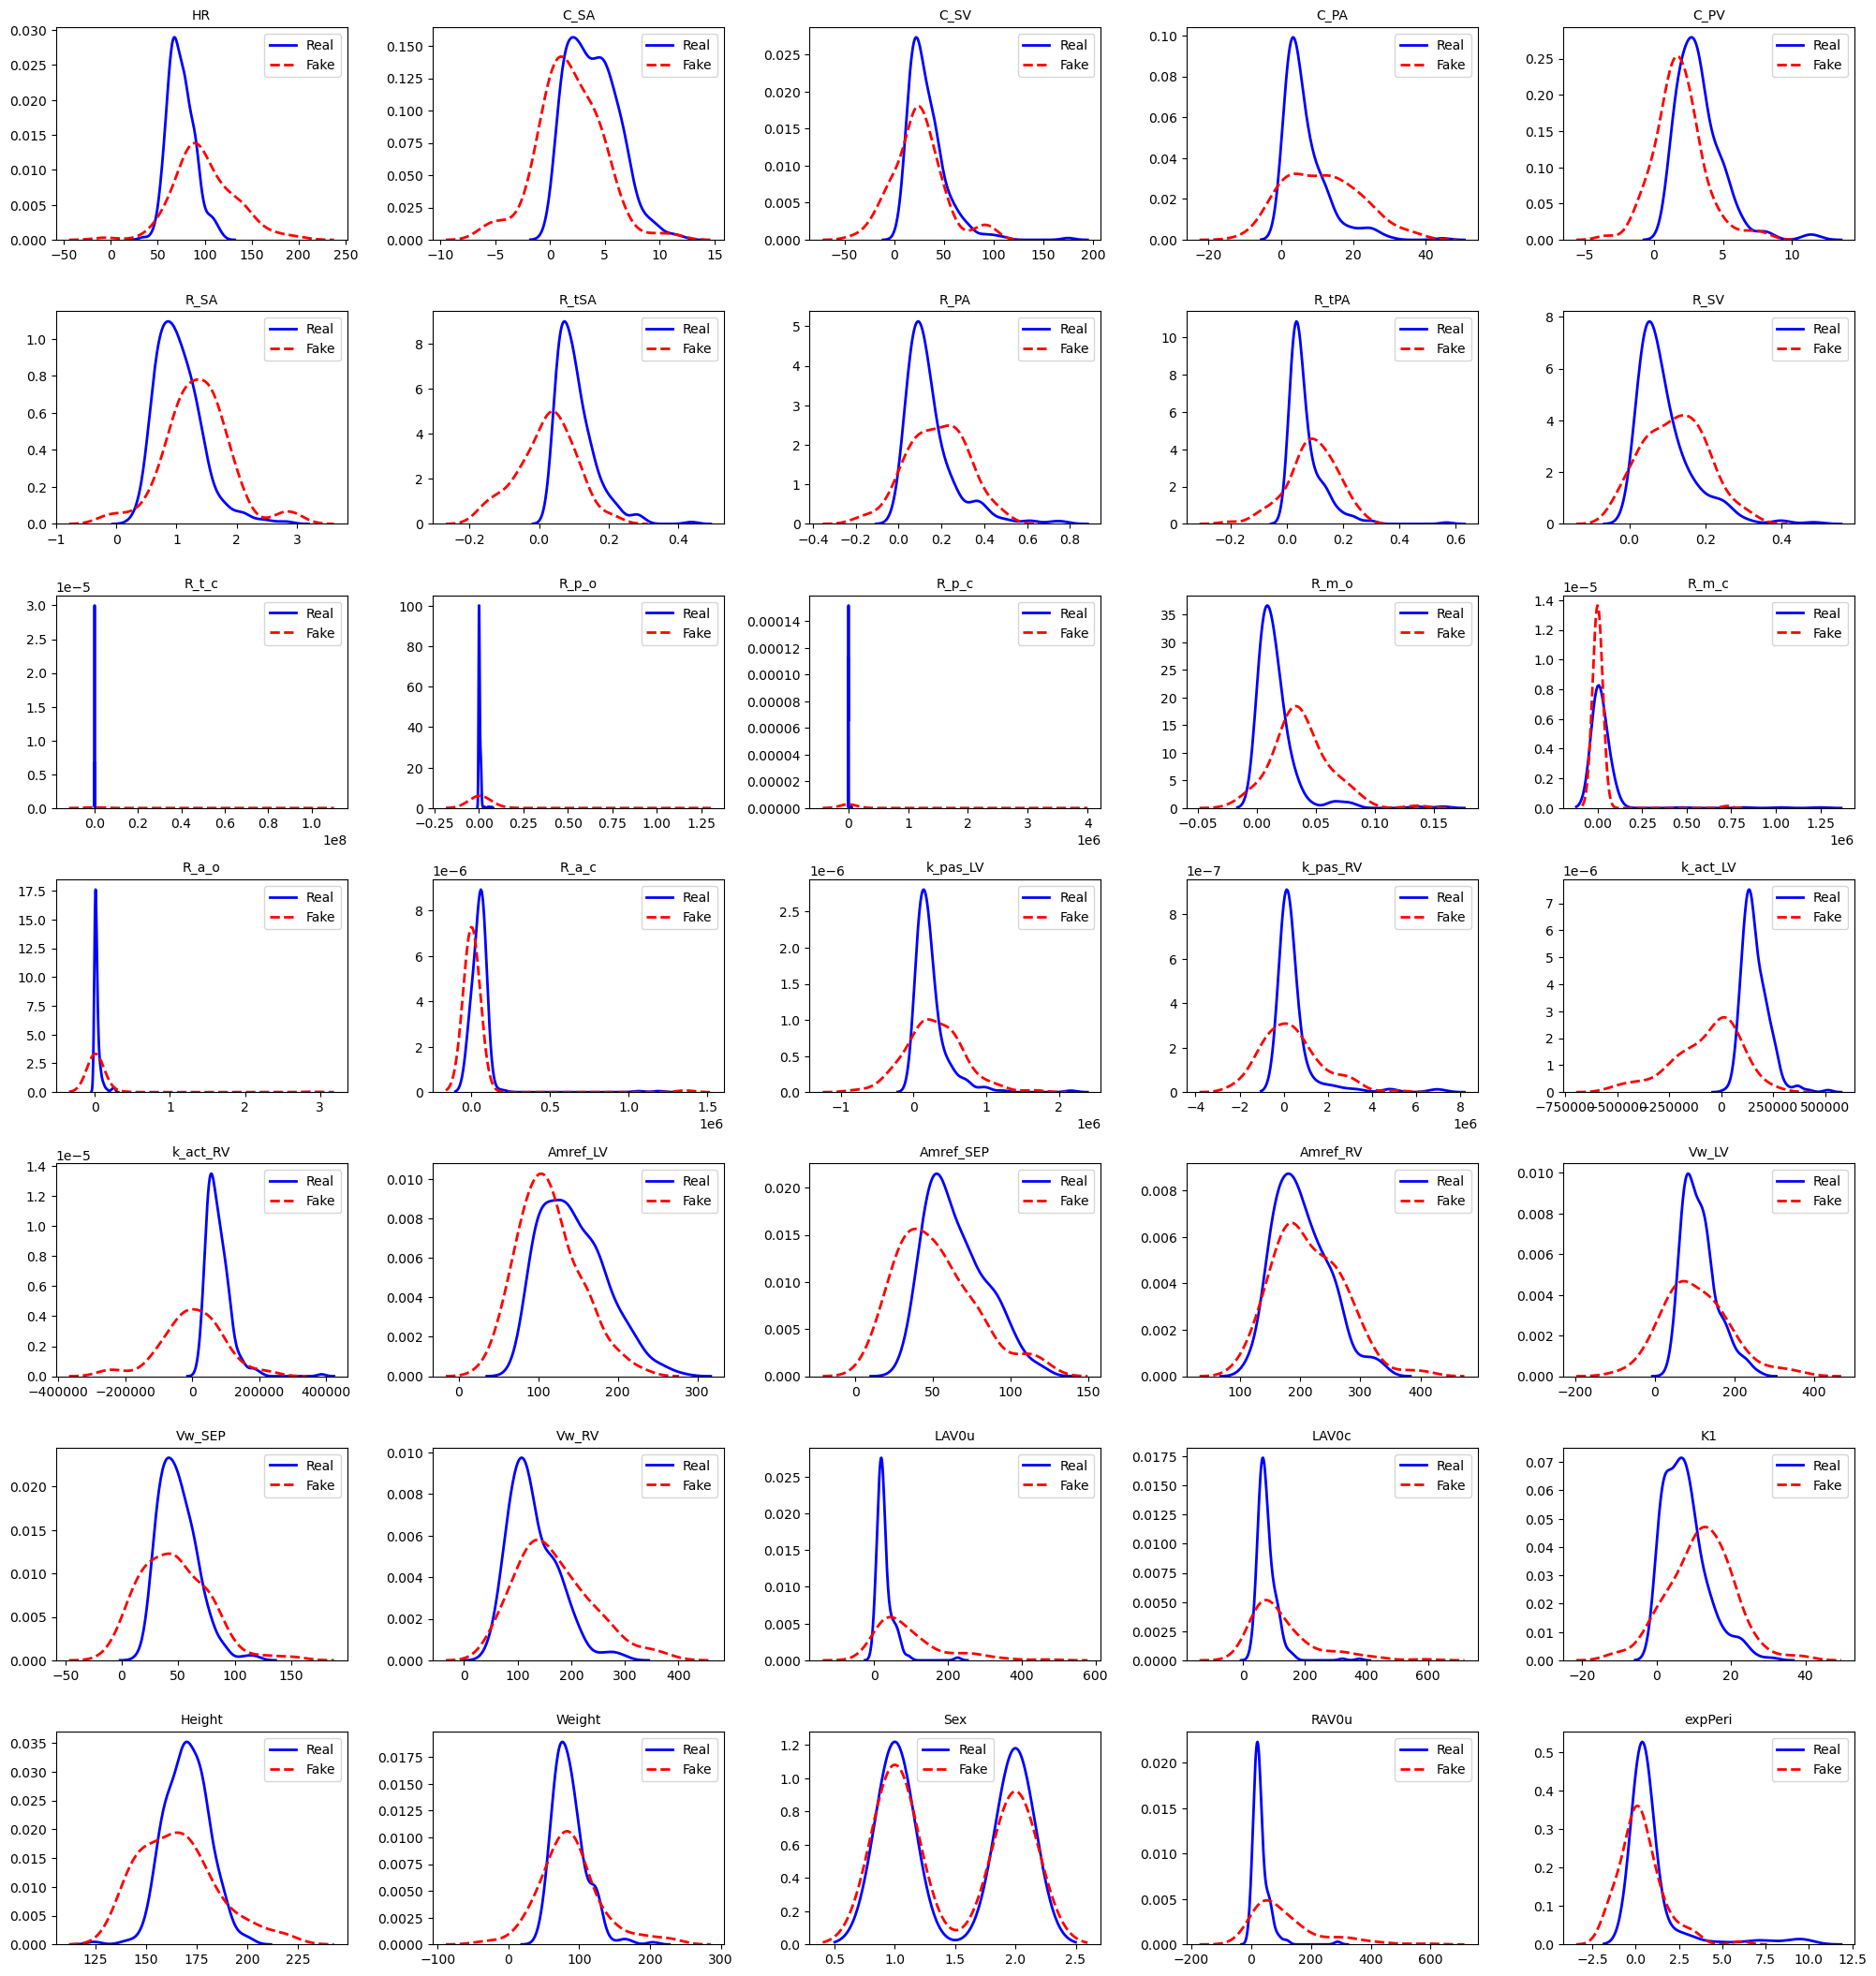

In [59]:
#import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_fake = pd.DataFrame(fake_data_original_scale, columns=df.columns)

# Number of features
num_cols = df.shape[1]

# Set up subplot grid
fig, axes = plt.subplots(nrows=num_cols // 5 + 1, ncols=5, figsize=(20, 3 * (num_cols // 5 + 1)))
axes = axes.flatten()

# Plot each feature's KDE for real and fake
for i, col in enumerate(df.columns):
    sns.kdeplot(df[col], ax=axes[i], label="Real", color="blue", linewidth=2)
    sns.kdeplot(df_fake[col], ax=axes[i], label="Fake", color="red", linestyle="--", linewidth=2)
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].legend()

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("Fakedata_PDF.pdf", bbox_inches='tight')
plt.savefig("Fakedata_PDF.png", dpi=300, bbox_inches='tight')
plt.show()


4.0
